KIỂM TRA SỐ LƯỢNG ẢNH

In [2]:
import os

data_dir = "datasets/neu_det"
phases = ["train", "validation"]

for phase in phases:
    print(f"==> Phase: {phase}")
    phase_dir = os.path.join(data_dir, phase)
    for class_name in os.listdir(phase_dir):
        class_dir = os.path.join(phase_dir, class_name)
        num_images = len(os.listdir(class_dir))
        print(f"   - {class_name}: {num_images} images")


==> Phase: train
   - crazing: 240 images
   - inclusion: 240 images
   - patches: 240 images
   - pitted_surface: 240 images
   - rolled-in_scale: 240 images
   - scratches: 240 images
==> Phase: validation
   - crazing: 60 images
   - inclusion: 60 images
   - patches: 60 images
   - pitted_surface: 60 images
   - rolled-in_scale: 60 images
   - scratches: 60 images


TIỀN XỬ LÝ VÀ AUGMENT

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.7, 1.3]
)


val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'datasets/neu_det/train',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    'datasets/neu_det/validation',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)


Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.


HUẤN LUYỆN MÔ HÌNH RESNET

In [24]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Định nghĩa input
input_tensor = Input(shape=(224, 224, 3))

# 2. Tải ResNet50 mà không có phần FC cuối cùng
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=input_tensor)

# 3. Đóng băng toàn bộ layer, chỉ fine-tune phần cuối
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

# 4. Xây head cho model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output_tensor = Dense(6, activation='softmax')(x)  # 6 classes

# 5. Khởi tạo model hoàn chỉnh
model = Model(inputs=input_tensor, outputs=output_tensor)

# 6. Compile
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 7. Summary
model.summary()


Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_9 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_9[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                            

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop]
)

# Lưu mô hình
model.save("resnet50_steel_functional.h5")

Epoch 1/30
45/45 [==============================] - 25s 466ms/step - loss: 1.6299 - accuracy: 0.3493 - val_loss: 2.0901 - val_accuracy: 0.1667
Epoch 2/30
45/45 [==============================] - 17s 374ms/step - loss: 1.1195 - accuracy: 0.5972 - val_loss: 2.0168 - val_accuracy: 0.1667
Epoch 3/30
45/45 [==============================] - 18s 400ms/step - loss: 0.8607 - accuracy: 0.7139 - val_loss: 2.0239 - val_accuracy: 0.1667
Epoch 4/30
45/45 [==============================] - 17s 387ms/step - loss: 0.7717 - accuracy: 0.7458 - val_loss: 1.9998 - val_accuracy: 0.1667
Epoch 5/30
45/45 [==============================] - 18s 388ms/step - loss: 0.6863 - accuracy: 0.7854 - val_loss: 1.9726 - val_accuracy: 0.1667
Epoch 6/30
45/45 [==============================] - 17s 382ms/step - loss: 0.6174 - accuracy: 0.7958 - val_loss: 1.9373 - val_accuracy: 0.1667
Epoch 7/30
45/45 [==============================] - 19s 423ms/step - loss: 0.5476 - accuracy: 0.8215 - val_loss: 1.8949 - val_accuracy: 0.1667

NHẬN XÉT MÔ HÌNH VÀ LƯU

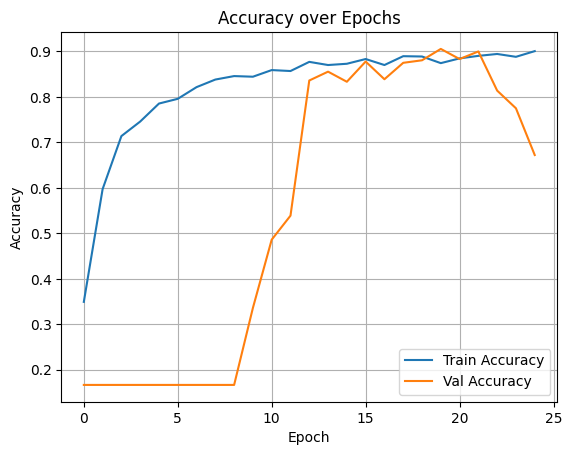

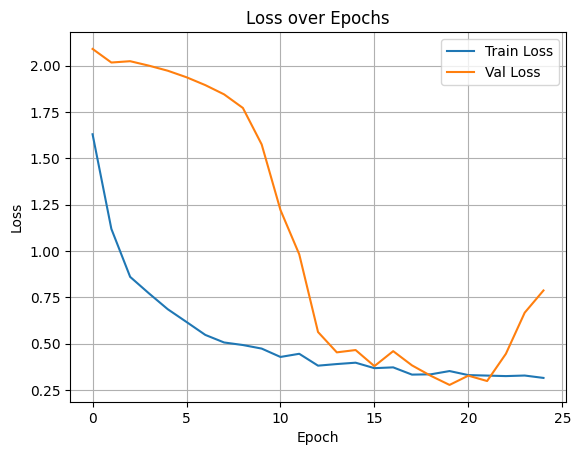

In [26]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [27]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Dự đoán trên validation set
val_generator.reset()
preds = model.predict(val_generator)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# In classification report
print(classification_report(y_true, y_pred, target_names=class_labels))


# Lưu nhãn lớp
import json
with open("class_indices.json", "w") as f:
    json.dump(val_generator.class_indices, f)


12/12 [==============================] - 3s 156ms/step
                 precision    recall  f1-score   support

        crazing       0.90      1.00      0.94        60
      inclusion       0.88      0.77      0.82        60
        patches       0.96      0.90      0.93        60
 pitted_surface       0.77      0.77      0.77        60
rolled-in_scale       0.97      1.00      0.98        60
      scratches       0.95      1.00      0.98        60

       accuracy                           0.91       360
      macro avg       0.91      0.91      0.90       360
   weighted avg       0.91      0.91      0.90       360



TEST ĐỘ NHẬN DIỆN BẰNG GRAD-CAM VỚI MÔ HÌNH VỪA TRAIN

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import gc
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image

def compute_gradcam(model, img_array, last_conv_layer_name, class_idx):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap + 1e-8)
    return heatmap

def detect_defect_with_gradcam_improved(img_path, class_names, threshold=0.5, draw_box=True):
    # Load mô hình
    model = load_model("resnet50_steel_functional.h5")

    # Đọc ảnh gốc (giữ nguyên kích thước thật)
    img_ori = cv2.imread(img_path)
    original_size = (img_ori.shape[1], img_ori.shape[0])

    # Resize về kích thước model (224x224)
    img_resized = cv2.resize(img_ori, (224, 224))
    img_array = img_resized / 255.0
    img_array_exp = np.expand_dims(img_array, axis=0)

    # Dự đoán
    preds = model.predict(img_array_exp)
    pred_index = np.argmax(preds[0])
    confidence = preds[0][pred_index]
    class_name = class_names[pred_index]

    # Grad-CAM
    heatmap = compute_gradcam(model, img_array_exp, "conv5_block3_out", pred_index)

    # Resize heatmap về kích thước ảnh gốc
    heatmap_resized = cv2.resize(heatmap, original_size)

    # Ngưỡng vùng nóng theo phần trăm
    threshold_value = np.percentile(heatmap_resized, 95)
    heatmap_binary = (heatmap_resized > threshold_value).astype(np.uint8) * 255

    # Làm mượt heatmap để giảm nhiễu
    kernel = np.ones((3, 3), np.uint8)
    heatmap_binary = cv2.morphologyEx(heatmap_binary, cv2.MORPH_OPEN, kernel)
    heatmap_binary = cv2.morphologyEx(heatmap_binary, cv2.MORPH_DILATE, kernel)

    contours, _ = cv2.findContours(heatmap_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Overlay heatmap lên ảnh gốc
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_ori, 0.6, heatmap_color, 0.4, 0)

    # Tính hot area
    hot_area = np.sum(heatmap_resized > threshold_value) / (original_size[0] * original_size[1])

    # Đánh giá lỗi
    if hot_area < 0.005 or confidence < 0.5:
        label = f"✅ Không có lỗi ({confidence:.2%})"
    else:
        label = f"❌ Có lỗi: {class_name} ({confidence:.2%})"
        if draw_box:
            for cnt in contours:
                if cv2.contourArea(cnt) > 200:  # loại bỏ vùng nhỏ
                    x, y, w, h = cv2.boundingRect(cnt)
                    cv2.rectangle(overlay, (x, y), (x + w, y + h), (0, 255, 0), 2)

    print(label)

    # Hiển thị kết quả
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(cv2.cvtColor(img_ori, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(heatmap_color)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f"Overlay with Box\n{label}")
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Giải phóng bộ nhớ
    tf.keras.backend.clear_session()
    gc.collect()


1/1 [==============================] - 1s 989ms/step
✅ Không có lỗi (49.49%)


C:\Users\MINH\AppData\Local\Temp\ipykernel_17568\1067428737.py:101: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


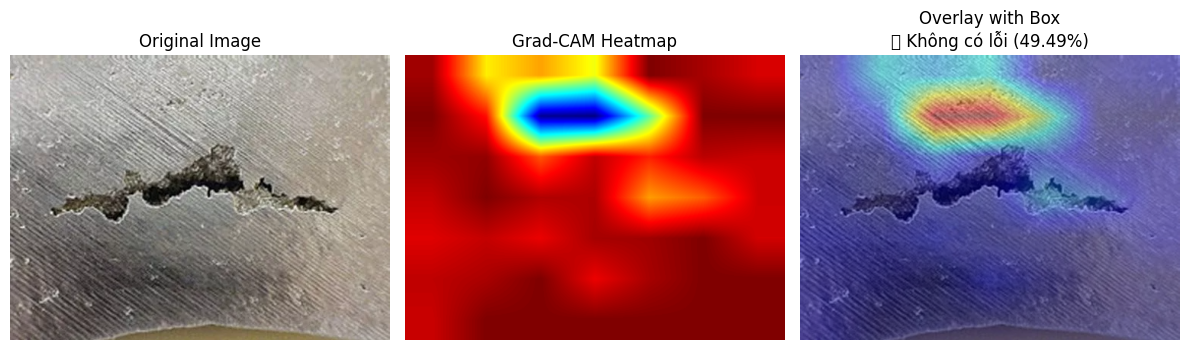

In [18]:
class_names = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
img_path = "test4.png"

detect_defect_with_gradcam_improved(img_path, class_names)

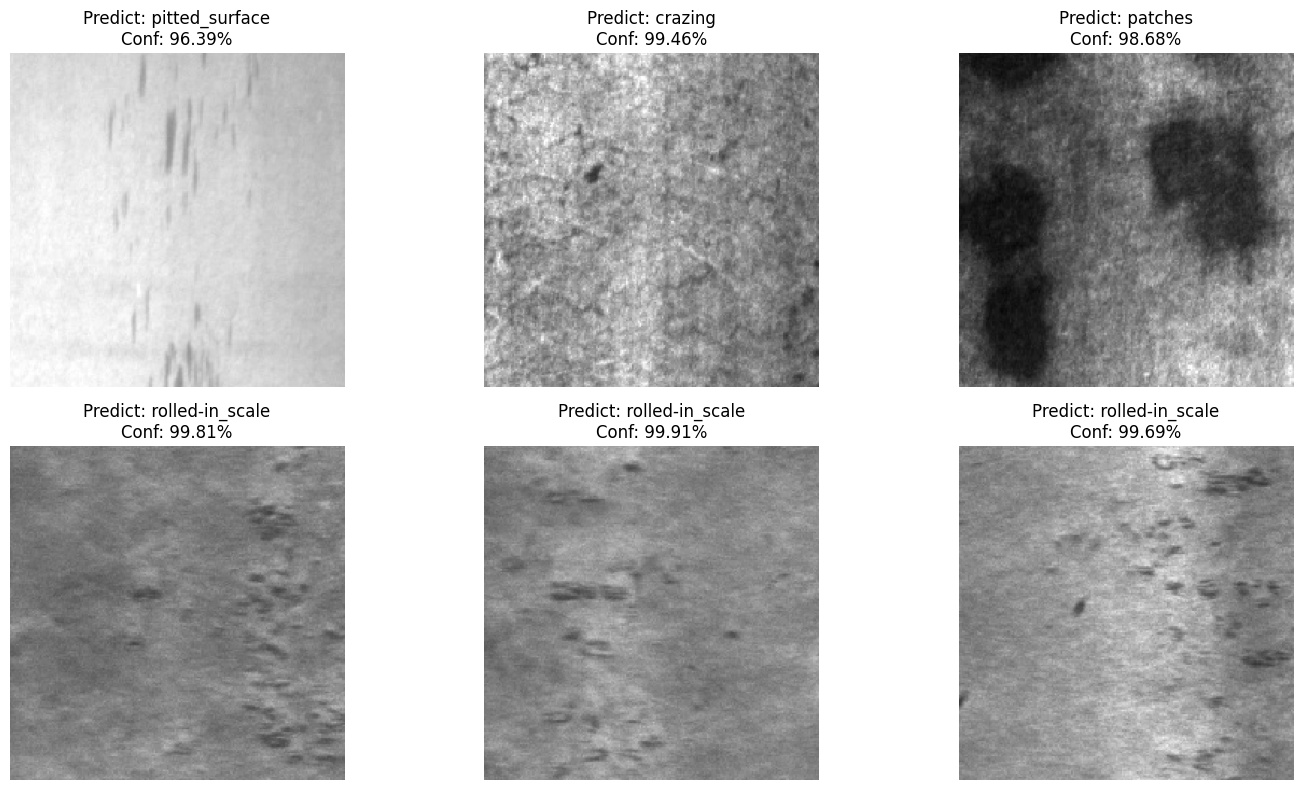

In [8]:
import os
import random
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# --- Cài đặt ---
train_dir = "datasets/neu_det/train"   
model_path = "resnet50_steel_functional.h5"
class_names = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

# --- Load model ---
model = load_model(model_path)

# --- Chọn ngẫu nhiên 6 ảnh ---
all_images = []
for label in class_names:
    label_path = os.path.join(train_dir, label)
    if os.path.isdir(label_path):
        imgs = [os.path.join(label_path, f) for f in os.listdir(label_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
        all_images.extend(imgs)

sample_images = random.sample(all_images, 6)

# --- Hàm xử lý ảnh ---
def preprocess(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0) / 255.0
    return arr

# --- Dự đoán và hiển thị ---
plt.figure(figsize=(15, 8))
for i, img_path in enumerate(sample_images):
    img_input = preprocess(img_path)
    preds = model.predict(img_input, verbose=0)
    pred_index = np.argmax(preds[0])
    confidence = preds[0][pred_index]
    label = class_names[pred_index]

    img_display = image.load_img(img_path, target_size=(224, 224))

    plt.subplot(2, 3, i+1)
    plt.imshow(img_display)
    plt.title(f"Predict: {label}\nConf: {confidence:.2%}")
    plt.axis('off')

plt.tight_layout()
plt.show()
